In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys

import pandas as pd # 引入 pandas，用于表格数据处理
import numpy as np  # 引入 numpy，用于数值计算
import scanpy as sc # 引入 scanpy，用于单细胞和空间转录组数据分析
import matplotlib.pyplot as plt  # 引入 matplotlib，用于绘图
import os # 引入 os，用于路径管理
import sys
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
from Train_SpaFre import train_Dual_SpaFre
# 设置随机种子确保结果可重现
np.random.seed(0)
import random
random.seed(0)

# 如果使用torch
try:
    import torch
    torch.manual_seed(0)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(0)
        torch.cuda.manual_seed_all(0)
except ImportError:
    pass

# scanpy的随机种子设置
sc.settings.seed = 0


from sklearn.metrics.cluster import adjusted_rand_score # 引入 ARI 评价指标，用于聚类结果评估

from utils import Cal_Spatial_Net, Transfer_pytorch_Data, mclust_R

In [2]:
# os.environ['R_HOME'] = '/root/miniconda3/lib/R'
# os.environ['R_USER'] = ' /root/miniconda3/lib/python3.10/site-packages/rpy2'
os.environ['R_HOME'] = 'C:\\Program Files\\R\\R-4.0.3'
os.environ['R_USER'] = ' D:\\Anaconda\\envs\\ST1\\Lib\\site-packages\\rpy2'
section_id = '151675'
#将文件路径 'D:\data\ST\stDCL\DLPFC' 和变量 section_id 拼接成一个完整的路径字符串，赋值给变量 input_dir
#os.path 是 Python 的 os 模块中负责路径处理的子模块
#join() 是其中的一个函数，用于跨平台安全地拼接路径

# input_dir = os.path.join('/home/waas/18298251859/data/DLPFC', section_id)  #这样写的好处就是只需修改 section_id，就可以自动切换不同的数据集，而不需要手动修改路径字符串
input_dir = os.path.join('D:\\data\\ST\\stDCL\\DLPFC', section_id)  #这样写的好处就是只需修改 section_id，就可以自动切换不同的数据集，而不需要手动修改路径字符串
# input_dir = os.path.join('/home/guest/hs/data/DLPFC', section_id)  #这样写的好处就是只需修改 section_id，就可以自动切换不同的数据集，而不需要手动修改路径字符串

#read_visium:Scanpy 中专门用于读取 10x Visium 空间转录组数据 的函数; path=input_dir:指向该样本所在的文件夹路径
# sc.read_visium(...)是 Scanpy 提供的一个高级数据读取接口，专门用来读取 10x Visium 平台的空间转录组数据。它会读取：
# 表达矩阵（.h5 文件或矩阵文件夹）
# 空间坐标（tissue_positions.csv）
# 图像数据（spatial/*.jpg）
# 标准化后的空间坐标（scalefactors_json.json）
adata = sc.read_visium(path=input_dir, count_file='filtered_feature_bc_matrix.h5')  #filtered_feature_bc_matrix.h5是默认的表达矩阵文件名，使用的是 CellRanger 输出的 HDF5 文件（包含基因-spot 表达矩阵）
print("adata",adata)
print(f"adata.shape:{adata.shape}")
print(type(adata))

adata AnnData object with n_obs × n_vars = 3592 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
adata.shape:(3592, 33538)
<class 'anndata._core.anndata.AnnData'>


In [3]:
adata.var_names_make_unique()  # 保证基因名唯一（变量名作为 DataFrame 的索引，必须唯一才能正确匹配）
#Normalization
# 数据预处理：选取高变基因 + 归一化 + log 转换
#有很多基因几乎在所有细胞/spot 中表达都差不多（“背景基因”）。更关心在不同细胞或空间位置变化明显的基因 —— 这些基因可能携带关键的生物学信号
#指定采用 Seurat v3 的方法 计算高变基因。这是一个成熟的、效果很好的变异度计算方法，考虑了表达量和方差的关系（拟合一个 loess 曲线）。其他可选方法还有 "cell_ranger"、"seurat"（v2），但 v3 是目前推荐的
#计算每个基因的均值和标准差，估计变异度（如方差/均值）和均值的拟合曲线，根据拟合结果计算每个基因的变异程度，从中选出 前 n_top_genes 个最显著的高变基因
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000) # 使用 Seurat v3 方法选择前 3000 个高变基因

sc.pp.normalize_total(adata, target_sum=1e4) # 将每个 spot 的表达量归一化为 1e4
sc.pp.log1p(adata)  # 对归一化后的数据取 log(1+x)

In [4]:
# Ann_df = pd.read_csv(os.path.join('/home/guest/hs/data/DLPFC', section_id, section_id+'_truth.txt'), sep='\t', header=None, index_col=0)
# Ann_df = pd.read_csv(os.path.join('/home/waas/18298251859/data/DLPFC', section_id, section_id+'_truth.txt'), sep='\t', header=None, index_col=0)
Ann_df = pd.read_csv(os.path.join('D:\\data\\ST\\stDCL\\DLPFC', section_id, section_id+'_truth.txt'), sep='\t', header=None, index_col=0)
Ann_df.columns = ['Ground Truth'] # 手动设置列名为 Ground Truth，因为之前 header=None 表示没有列名
#将 Ann_df 中的 Ground Truth 标签添加到 AnnData 对象 adata 的 .obs 属性中，作为新的列 Ground Truth
# adata.obs_names 是 AnnData 中所有观察对象的 ID（通常是 spot/cell 的 ID）
# 将每个 spot/cell 的真实标签匹配出来，准备赋值给 adata.obs
adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth']  # 将 ground truth 添加到 AnnData 对象的 obs 中

In [5]:
Cal_Spatial_Net(adata, rad_cutoff=150)

adata = train_Dual_SpaFre(adata,
                           hidden_dims=[512, 30],
                           n_epochs=1500,
                           K=4,
                           init_tau=0.8,
                           init_homo_ratio=0.8,
                           init_gating_weight=0.8)

sc.pp.neighbors(adata, use_rep='SpaFre')
sc.tl.umap(adata)

------Calculating spatial graph...
The graph contains 20762 edges, 3592 cells.
5.7801 neighbors per cell on average.
--- Constructing Graph Propagation Operator ---
matrix multiplication time:  0.0009987354278564453
propagate matrix time:  0.19332432746887207
sparse_mx:  0.002999544143676758
Initial tau: 0.8000
Initial homo_ratio: 0.8000
Initial gating_weight: 0.8000


  0%|          | 1/1500 [00:05<2:18:59,  5.56s/it]

Epoch 1: tau = 0.799840, homo_ratio = 0.799840, gating_weight = 0.799840


  0%|          | 2/1500 [00:10<2:13:36,  5.35s/it]

Epoch 2: tau = 0.799680, homo_ratio = 0.799680, gating_weight = 0.799680


  0%|          | 3/1500 [00:15<2:09:36,  5.20s/it]

Epoch 3: tau = 0.799519, homo_ratio = 0.799520, gating_weight = 0.799524


  0%|          | 3/1500 [00:19<2:40:19,  6.43s/it]


KeyboardInterrupt: 

In [13]:
import rpy2.robjects as robjects
robjects.r('set.seed(0)')

adata = mclust_R(adata, used_obsm='SpaFre', num_cluster=5)
label_df = adata.obs['mclust']
# label_df.to_csv(f"/home/guest/hs/111/STAGATE_333/result/our(H)_{section_id}.csv")
# label_df.to_csv(rf"D:\Code\1ST\STAGATE_pyG-main\STAGATE_pyG-main\STAGATE_333\result\our1_{section_id}.csv")
print("保存成功")
# df = pd.read_csv("/home/guest/hs/111/STAGATE_333/")
# adata.obs['mclust'] = df.iloc[:,0].values
# 计算聚类结果的 ARI（调整兰德指数）来评估与 ground truth 的相似度
obs_df = adata.obs.dropna()   # dropna() 的作用是：删除包含缺失值（NaN）的行
ARI = adjusted_rand_score(obs_df['mclust'], obs_df['Ground Truth'])   # 评估聚类结果与真实标签之间的一致性； adjusted_rand_score()用于衡量两个分类（聚类）结果之间的相似度
print('Adjusted rand index = %.2f' %ARI)

fitting ...
  |======================================================================| 100%
保存成功
Adjusted rand index = 0.25


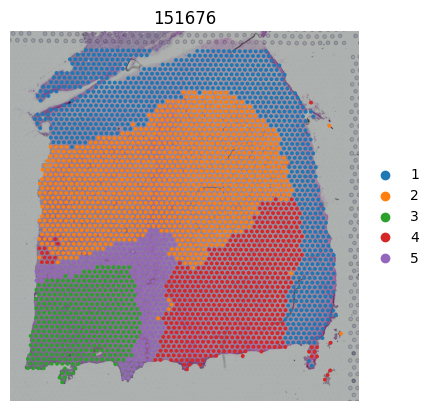

In [14]:
fig=sc.pl.spatial(adata,# AnnData对象
                  color="mclust",# 着色依据：聚类结果
                  title=f"{section_id}",# 图形标题
                  spot_size=100,
                  frameon=False,
                  show = True)

In [8]:
save_dir = '/home/guest/hs/111/STAGATE_333/result/DLPFC(H)'
os.makedirs(save_dir, exist_ok=True)
fig=sc.pl.spatial(adata,# AnnData对象
                  color="mclust",# 着色依据：聚类结果
                  title=f"{section_id}-(ARI={ARI:.4f})",# 图形标题
                  spot_size=100,
                  frameon=False,
                  show = False)
plt.savefig(f'{save_dir}/spatial_plot_{section_id}.png',
            dpi=150,
            bbox_inches='tight')
plt.close()

In [9]:
adata.write_h5ad(f'/home/guest/hs/111/STAGATE_333/result/DLPFC(H)/our(H)_{section_id}.h5ad')

In [10]:
# 保存聚类标签
label_df = adata.obs['mclust']
label_df.to_csv(f'/home/guest/hs/111/STAGATE_333/result/DLPFC(H)/our_label(H)_{section_id}.csv')

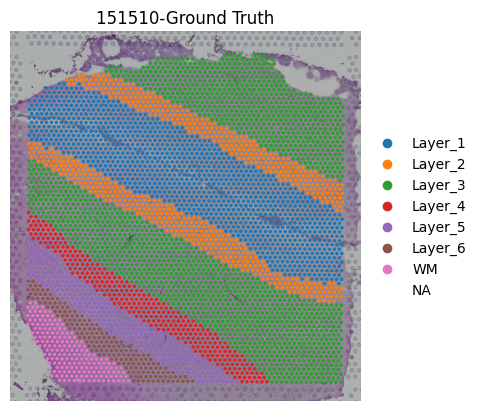

In [11]:
fig=sc.pl.spatial(adata,# AnnData对象
                  color="Ground Truth",# 着色依据：聚类结果
                  title=f"{section_id}-Ground Truth",# 图形标题
                  spot_size=100,
                  frameon=False,
                  show = True)

In [7]:
save_dir = '/home/guest/hs/111/STAGATE_333/result/DLPFC'
os.makedirs(save_dir, exist_ok=True)
fig=sc.pl.spatial(adata,# AnnData对象
                  color="Ground Truth",# 着色依据：聚类结果
                  title=f"{section_id}-Ground Truth",# 图形标题
                  spot_size=100,
                  frameon=False,
                  show = False)
plt.savefig(f'{save_dir}/Ground Truth_{section_id}.png',
            dpi=150,
            bbox_inches='tight')
plt.close()

In [9]:
adata.write_h5ad(f'/home/guest/hs/111/STAGATE_333/result/DLPFC(H)/our(H)_{section_id}.h5ad')